In [39]:
import os
import getpass
from typing import Literal

from langchain_openai import ChatOpenAI
from crewai_tools import SerperDevTool
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.graph import START, StateGraph, END
from typing import TypedDict

In [22]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")
os.environ["SERPER_API_KEY"] = getpass.getpass("Enter your Serper API key: ")

In [45]:
@tool
def serper_search(user_query: str) -> str:
    """
    Perform a real-time search using the Serper API.

    This tool takes a plain-text user query, sends it to Serper (a web search API),
    and returns a string with the top relevant results. It can be used by agents
    to gather up-to-date information from the internet as part of a reasoning or
    research task.

    Args:
        user_query (str): A natural language search prompt.

    Returns:
        str: A formatted string of search results from Serper.
    """
    print("--- Search Node ---")
    result = SerperDevTool().run(query=user_query)
    return result

In [46]:
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

In [47]:
class AgentState(TypedDict):
    user_query: str
    answer: str

In [48]:
def search_agent(state: AgentState) -> str:
    """
    Executes an agent that processes a user query.

    This function takes the current state (which includes the user's question),
    creates an agent using the Openai language model and the `serper_search` tool,
    then runs the agent to get a response. The final answer is returned as updated state.

    Args:
        state (AgentState): A dictionary with the user's query.

    Returns:
        dict: Updated state with the generated answer.
    """
    agent = create_agent(llm, [serper_search])
    result = agent.invoke({"messages": state["user_query"]})
    return {"answer": result["messages"][-1].content}

In [34]:
workflow = StateGraph(AgentState)

workflow.add_node("search_agent", search_agent)

workflow.add_edge(START, "search_agent")
workflow.add_edge("search_agent", END)

app = workflow.compile()

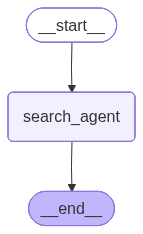

In [35]:
from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())

In [36]:
result = app.invoke({"user_query": "Who won the IPL 2025 final?"})
print(result["answer"])

Using Tool: Search the internet with Serper
The winner of the IPL 2025 final was **Royal Challengers Bengaluru**. They won the final match by 6 runs against Punjab Kings. This victory marked Royal Challengers Bengaluru's first IPL title after 18 years.


In [49]:
def math_agent(state: AgentState) -> str:
    """
    A math-solving agent that uses the LLM to process and solve math problems.

    Args:
        state (AgentState): Contains the user's query.

    Returns:
        dict: Updated state with the computed answer from the LLM.
    """
    print("--- Math Node ---")
    prompt = f"Solve this math problem and return only the answer: {state['user_query']}"
    response = llm.invoke(prompt)
    state['answer'] = response.content.strip()
    return state

In [50]:
def router_agent(state: AgentState) -> str:
    """
    Captures a user query from the command line and updates the state.

    This function acts as an input node in the LangGraph workflow. It prompts the user
    to enter a query via the console, then stores that input in the shared state under
    the 'user_query' key, which will be used to route to the appropriate agents.

    Args:
        state (AgentState): The current state dictionary (can be empty or partially filled).

    Returns:
        dict: Updated state containing the user's query.
    """
    print("--- Router Node ---")
    state['user_query'] = input("Input user query: ")
    return state

In [51]:
agent_docs = {
    "search_agent": search_agent.__doc__,
    "math_agent": math_agent.__doc__
}

In [52]:
def routing_logic(state: AgentState) -> Literal["math_agent", "search_agent"]:
    """
    Uses the LLM to choose between 'math_agent' and 'search_agent'
    based on the intent of the user query and the agents' docstrings.

    Args:
        state (AgentState): The current state containing the user query.

    Returns:
        str: The name of the next node to route to.
    """
    prompt = f"""
    You are a router agent. Your task is to choose the best agent for the job.
    Here is the user query: {state['user_query']}

    You can choose from the following agents:
    - math_agent: {agent_docs['math_agent']}
    - search_agent: {agent_docs['search_agent']}

    Which agent should handle this query? Respond with just the agent name.
    """
    response = llm.invoke(prompt)
    decision = response.content.strip().lower()
    return "math_agent" if "math" in decision else "search_agent"

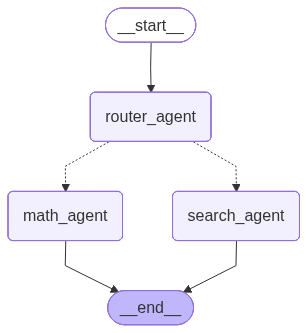

In [53]:
workflow = StateGraph(AgentState)
workflow.add_node("router_agent", router_agent) # Adds the new router agent to the flow
workflow.add_node("search_agent", search_agent) # Adds the search agent to the flow
workflow.add_node("math_agent", math_agent) # Adds the math agent to the flow

workflow.add_edge(START, "router_agent")
workflow.add_conditional_edges("router_agent", routing_logic)
workflow.add_edge("search_agent", END)
workflow.add_edge("math_agent", END)

app = workflow.compile()

from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())

In [54]:
app.invoke({})["answer"] # test for search node

--- Router Node ---
--- Search Node ---
Using Tool: Search the internet with Serper


"I couldn't find specific information about Sajad Safarveisi working at Cognism. If you need more details or have any other questions, feel free to ask!"

In [55]:
app.invoke({})["answer"] # test for search node

--- Router Node ---
--- Math Node ---


'300'